# EMiF Project Final - Has the structure of risk in financial markets changed since COVID-19?

This master notebook reproduces the full empirical pipeline in one place. It does not rely on pre-computed CSV files: it rebuilds the cleaned dataset, reruns the volatility and dependence models, and regenerates the tables and figures used to answer the research question.


## 1. Setup and reproducibility logic

We begin by importing the packages and helper modules used throughout the project. The code is written so that the notebook runs from the single Excel workbook `Data.xlsx`, with no external data source and no hidden preprocessing step.


In [1]:
from _notebook_setup import bootstrap_notebook

bootstrap_notebook()

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from project2_config import TABLE_DIR, DISPLAY_NAMES, PRICE_COLUMNS, YIELD_COLUMNS, COVID_BREAK
from project2_data_utils import (
    ensure_output_dirs,
    load_raw_data,
    build_aligned_returns,
    split_pre_post,
    build_stylized_facts_table,
    stationarity_test_table,
    variance_chow_test,
    quandt_andrews_style_variance_test,
    cusum_variance_break_test,
    bai_perron_style_breaks,
    plot_level_panel,
    plot_correlation_heatmaps,
    plot_acf_grid,
    plot_variance_breaks,
    save_figure,
)
from project2_garch_utils import (
    GARCH_ASSETS,
    estimate_all_garch_models,
    build_comparison_table,
    plot_conditional_volatility,
    save_garch_outputs,
)
from project2_multivariate_utils import (
    KEY_PAIRS,
    DCC_PAIRS,
    PAIR_LABELS,
    rolling_correlation_table,
    summarize_rolling_correlations,
    plot_rolling_correlations,
    fit_bivariate_dcc,
    summarize_dcc_path,
    plot_dcc_path,
    build_forbes_rigobon_table,
    save_multivariate_outputs,
)
from project2_var_utils import (
    VAR_COLUMNS,
    VAR_LAG,
    fit_var,
    var_order_selection,
    var_summary_row,
    granger_table,
    geweke_causality_table,
    plot_irf_panel,
    save_var_outputs,
)
from project2_regime_utils import (
    load_regime_data,
    fit_two_state_markov,
    markov_summary_table,
    smoothed_probability_table,
    plot_smoothed_probabilities,
    run_break_detection,
    plot_breaks,
    pre_post_break_count,
    save_regime_outputs,
)

ensure_output_dirs()

## 2. Research question and empirical design

The project asks whether the **structure of risk** changed after COVID-19. We interpret risk structure broadly, in line with the course and the project brief:

- the level and shape of market risk;
- the persistence and asymmetry of volatility;
- the correlation and dependence structure across assets;
- the direction and intensity of risk transmission;
- the existence of regimes and structural breaks.

To stay close to the prompt, we compare two calendar subsamples:

- **Pre-COVID:** 2000-2019;
- **Post-COVID:** 2020 onward.

Separately, we keep **11 March 2020** as the economic event date to test and visualize, because the project instructions explicitly ask for a statistical justification of a COVID breakpoint.


## 3. Data loading, transformations and sample split

We load the 14 series from the Excel workbook, align the dates by dropping missing observations after transformation, and construct the returns used in the econometric work.

Economically, the transformations follow the project brief closely:

- price and index series are converted into **daily log returns in percent**;
- yield series are converted into **daily first differences in basis points**;
- **oil is the only deliberate exception**: because the WTI contract printed a negative settlement in April 2020, a standard log return would be undefined exactly in the crisis window that matters for the project. We therefore use a simple percentage return for oil and document this choice explicitly.


In [2]:
raw_data = load_raw_data()
level_data, aligned_returns = build_aligned_returns(raw_data)
pre_covid, post_covid = split_pre_post(aligned_returns)

sample_summary = pd.DataFrame([
    {
        "sample": "Full sample",
        "start_date": aligned_returns["date"].min().date(),
        "end_date": aligned_returns["date"].max().date(),
        "n_obs": len(aligned_returns),
    },
    {
        "sample": "Pre-COVID (2000-2019)",
        "start_date": pre_covid["date"].min().date(),
        "end_date": pre_covid["date"].max().date(),
        "n_obs": len(pre_covid),
    },
    {
        "sample": "Post-COVID (2020+)",
        "start_date": post_covid["date"].min().date(),
        "end_date": post_covid["date"].max().date(),
        "n_obs": len(post_covid),
    },
])

transformation_table = pd.DataFrame({
    "series": PRICE_COLUMNS + YIELD_COLUMNS,
    "label": [DISPLAY_NAMES.get(col, col) for col in PRICE_COLUMNS + YIELD_COLUMNS],
    "transformation": [
        "log return (%)" if col != "oil" else "simple return (%) because WTI turns negative in April 2020"
        for col in PRICE_COLUMNS
    ] + ["first difference (bp)" for _ in YIELD_COLUMNS],
})

display(sample_summary)
display(transformation_table)


,sample,start_date,end_date,n_obs
0,Full sample,2000-01-05,2026-04-24,5486
1,Pre-COVID (2000-2019),2000-01-05,2019-12-30,4181
2,Post-COVID (2020+),2020-01-06,2026-04-24,1305


,series,label,transformation
0,sp500,S&P 500,log return (%)
1,eurostoxx50,Euro Stoxx 50,log return (%)
2,hang_seng,Hang Seng,log return (%)
3,msci_em,MSCI EM,log return (%)
4,smi,SMI,log return (%)
5,oil,Oil futures,simple return (%) because WTI turns negative i...
6,gold,Gold,log return (%)
7,eurusd,EURUSD,log return (%)
8,usdjpy,USDJPY,log return (%)
9,us_ig_bonds,US IG bonds,log return (%)


## 4. Stylized facts and break-date justification

We start with descriptive evidence because any argument about a changed risk structure should first appear in moments, tail risk, volatility clustering and cross-asset dependence. We also report simple stationarity checks on the transformed series, because the later GARCH, DCC and VAR models are all built on that daily-return representation.

For the COVID event date, we keep **11 March 2020** for its clear economic interpretation, but we do not rely on narrative alone. We complement the imposed break-date test with a break scan, a multiple-break procedure and a CUSUM stability test on the variance proxy.

C:\Users\loren\emif-project-2-risk-structure-after-covid\src\project2_data_utils.py:152: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression="c", nlags="auto")
C:\Users\loren\emif-project-2-risk-structure-after-covid\src\project2_data_utils.py:152: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression="c", nlags="auto")
C:\Users\loren\emif-project-2-risk-structure-after-covid\src\project2_data_utils.py:152: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression="c", nlags="auto")
C:\Users\l

,sample,asset,n_obs,mean_daily,std_daily,skewness,excess_kurtosis,jarque_bera_stat,jarque_bera_pvalue,anderson_darling_stat,anderson_darling_pvalue,var_5pct,es_5pct,max_drawdown,asset_label
19,Post-COVID (2020+),oil,1305,-0.1600,9.7606,-25.2335,761.4261,31421916.8998,0.0000,254.1637,0.0000,-4.0384,-13.5972,-0.9947,Oil futures
14,Post-COVID (2020+),sp500,1305,0.0507,1.3331,-0.6241,15.9552,13812.9254,0.0000,29.9274,0.0000,-1.7842,-3.2002,-0.3395,S&P 500
24,Post-COVID (2020+),us_hy_bonds,1305,0.0178,0.4074,-1.6787,26.7270,39143.1901,0.0000,67.6239,0.0000,-0.5192,-1.0015,-0.2131,US HY bonds
26,Post-COVID (2020+),ust10y_yield,1305,0.0645,6.1297,-0.1545,2.4364,324.2811,0.0000,3.7472,0.0000,-9.8220,-13.9147,NaN,US 10Y yield change (bp)
5,Pre-COVID (2000-2019),oil,4181,0.0834,2.3195,0.2317,4.4574,3488.1055,0.0000,26.0363,0.0000,-3.5696,-5.0999,-0.7023,Oil futures
0,Pre-COVID (2000-2019),sp500,4181,0.0156,1.1624,-0.3265,7.5226,9905.1675,0.0000,inf,0.0000,-1.8654,-2.8481,-0.6644,S&P 500
10,Pre-COVID (2000-2019),us_hy_bonds,4181,0.0277,0.2805,-2.6366,42.4241,317610.9295,0.0000,inf,0.0000,-0.3602,-0.6890,-0.2984,US HY bonds
12,Pre-COVID (2000-2019),ust10y_yield,4181,-0.1157,5.8122,0.0005,2.3805,983.6429,0.0000,9.7113,0.0000,-9.1800,-12.6228,NaN,US 10Y yield change (bp)


,sample,variable,variable_label,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
0,Pre-COVID (2000-2019),sp500,S&P 500,-14.4760,0.0000,0.9383,0.0100
1,Pre-COVID (2000-2019),ust10y_yield,US 10Y yield change (bp),-47.7633,0.0000,0.3106,0.1000
2,Pre-COVID (2000-2019),oil,Oil futures,-17.8367,0.0000,0.0867,0.1000
3,Pre-COVID (2000-2019),eurusd,EURUSD,-65.1069,0.0000,0.0818,0.1000
4,Pre-COVID (2000-2019),us_hy_bonds,US HY bonds,-9.6512,0.0000,0.0696,0.1000
5,Post-COVID (2020+),sp500,S&P 500,-10.4802,0.0000,0.0995,0.1000
6,Post-COVID (2020+),ust10y_yield,US 10Y yield change (bp),-27.8428,0.0000,0.1124,0.1000
7,Post-COVID (2020+),oil,Oil futures,-8.1586,0.0000,0.2728,0.1000
8,Post-COVID (2020+),eurusd,EURUSD,-35.3802,0.0000,0.1914,0.1000
9,Post-COVID (2020+),us_hy_bonds,US HY bonds,-11.5239,0.0000,0.1617,0.1000


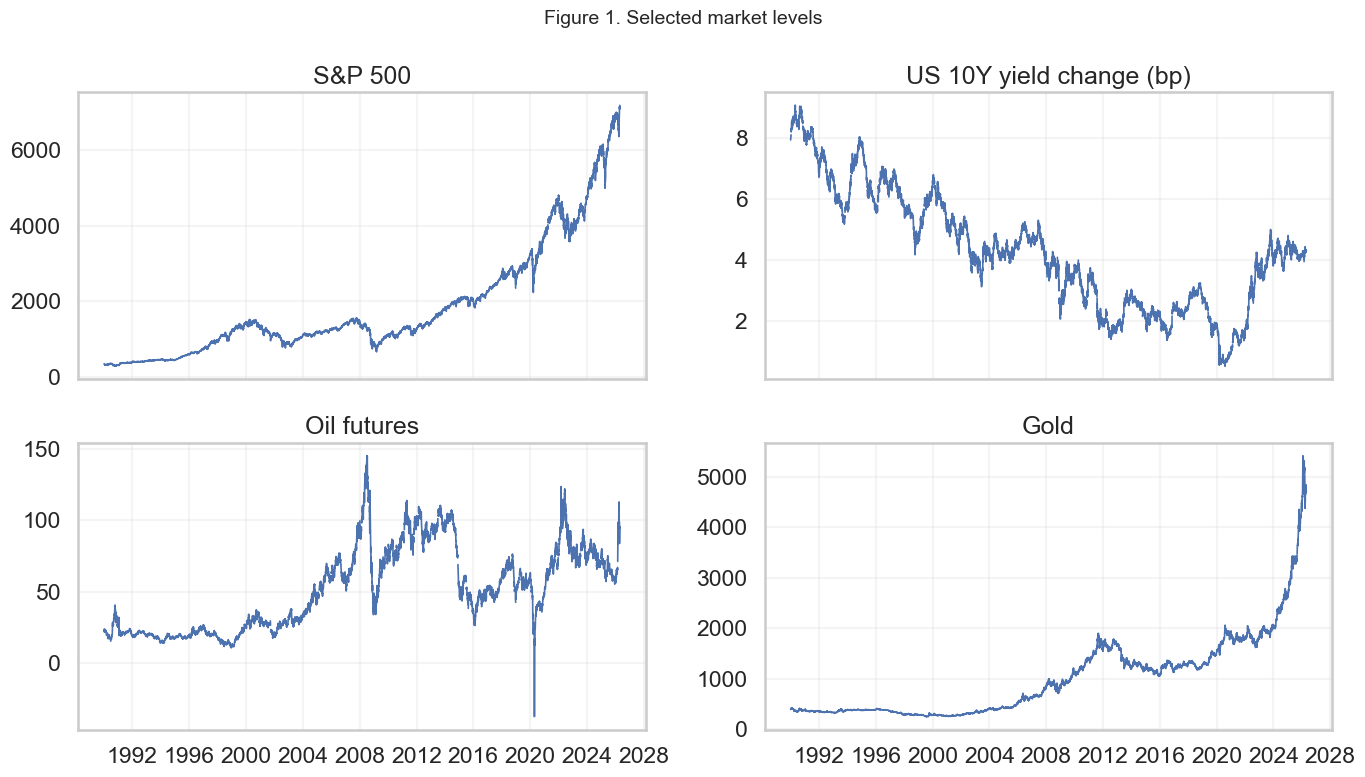

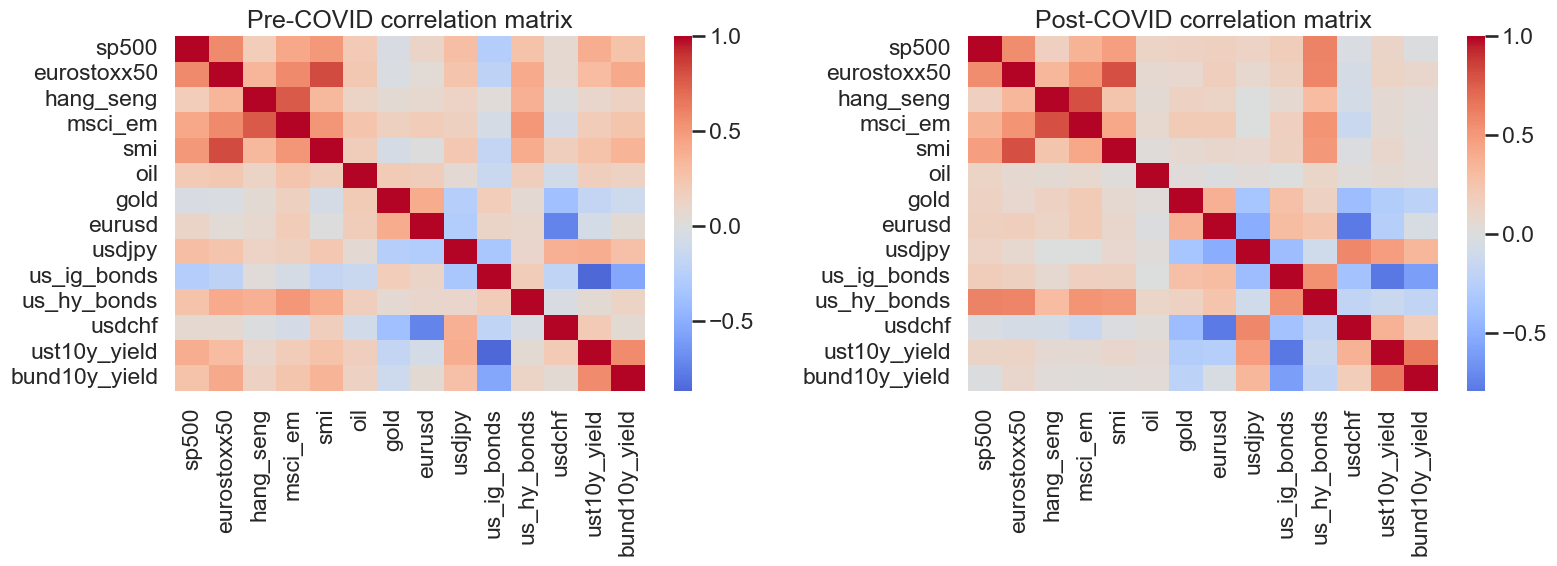

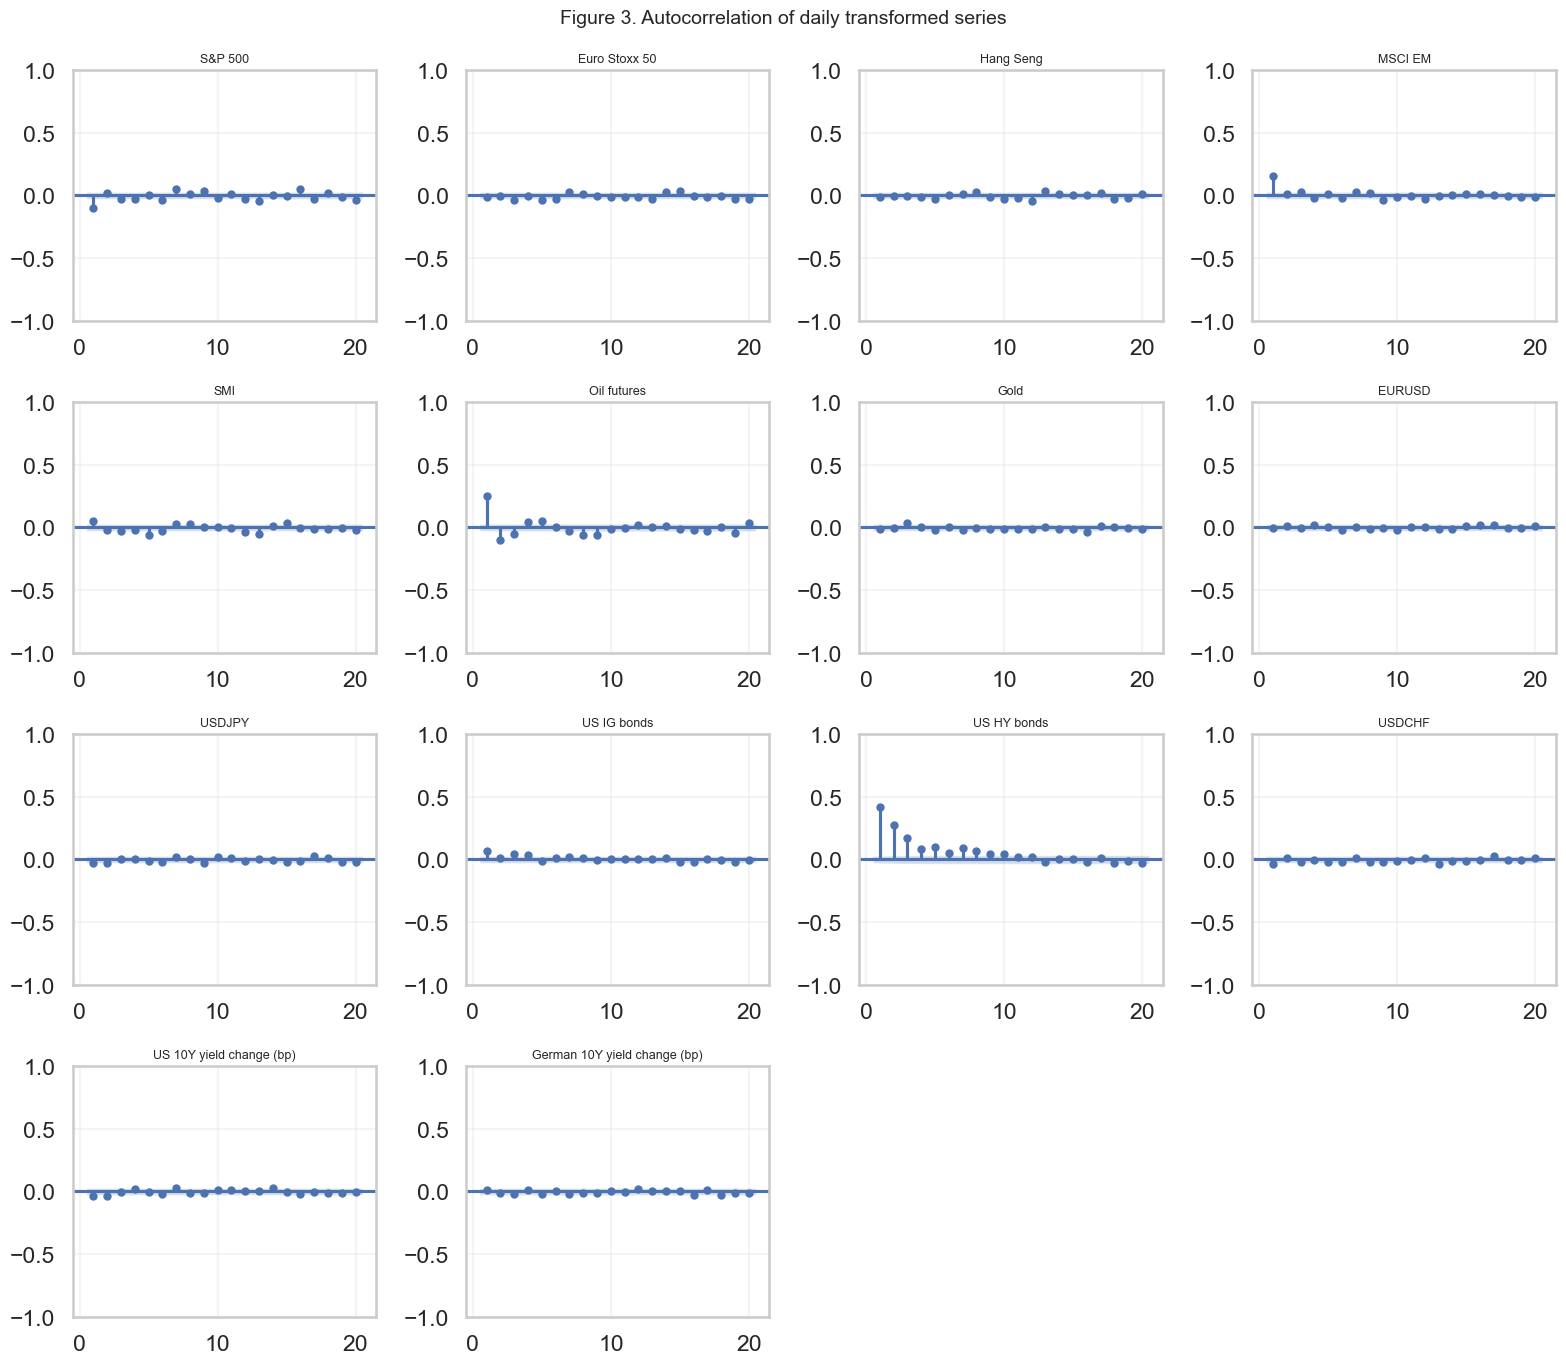

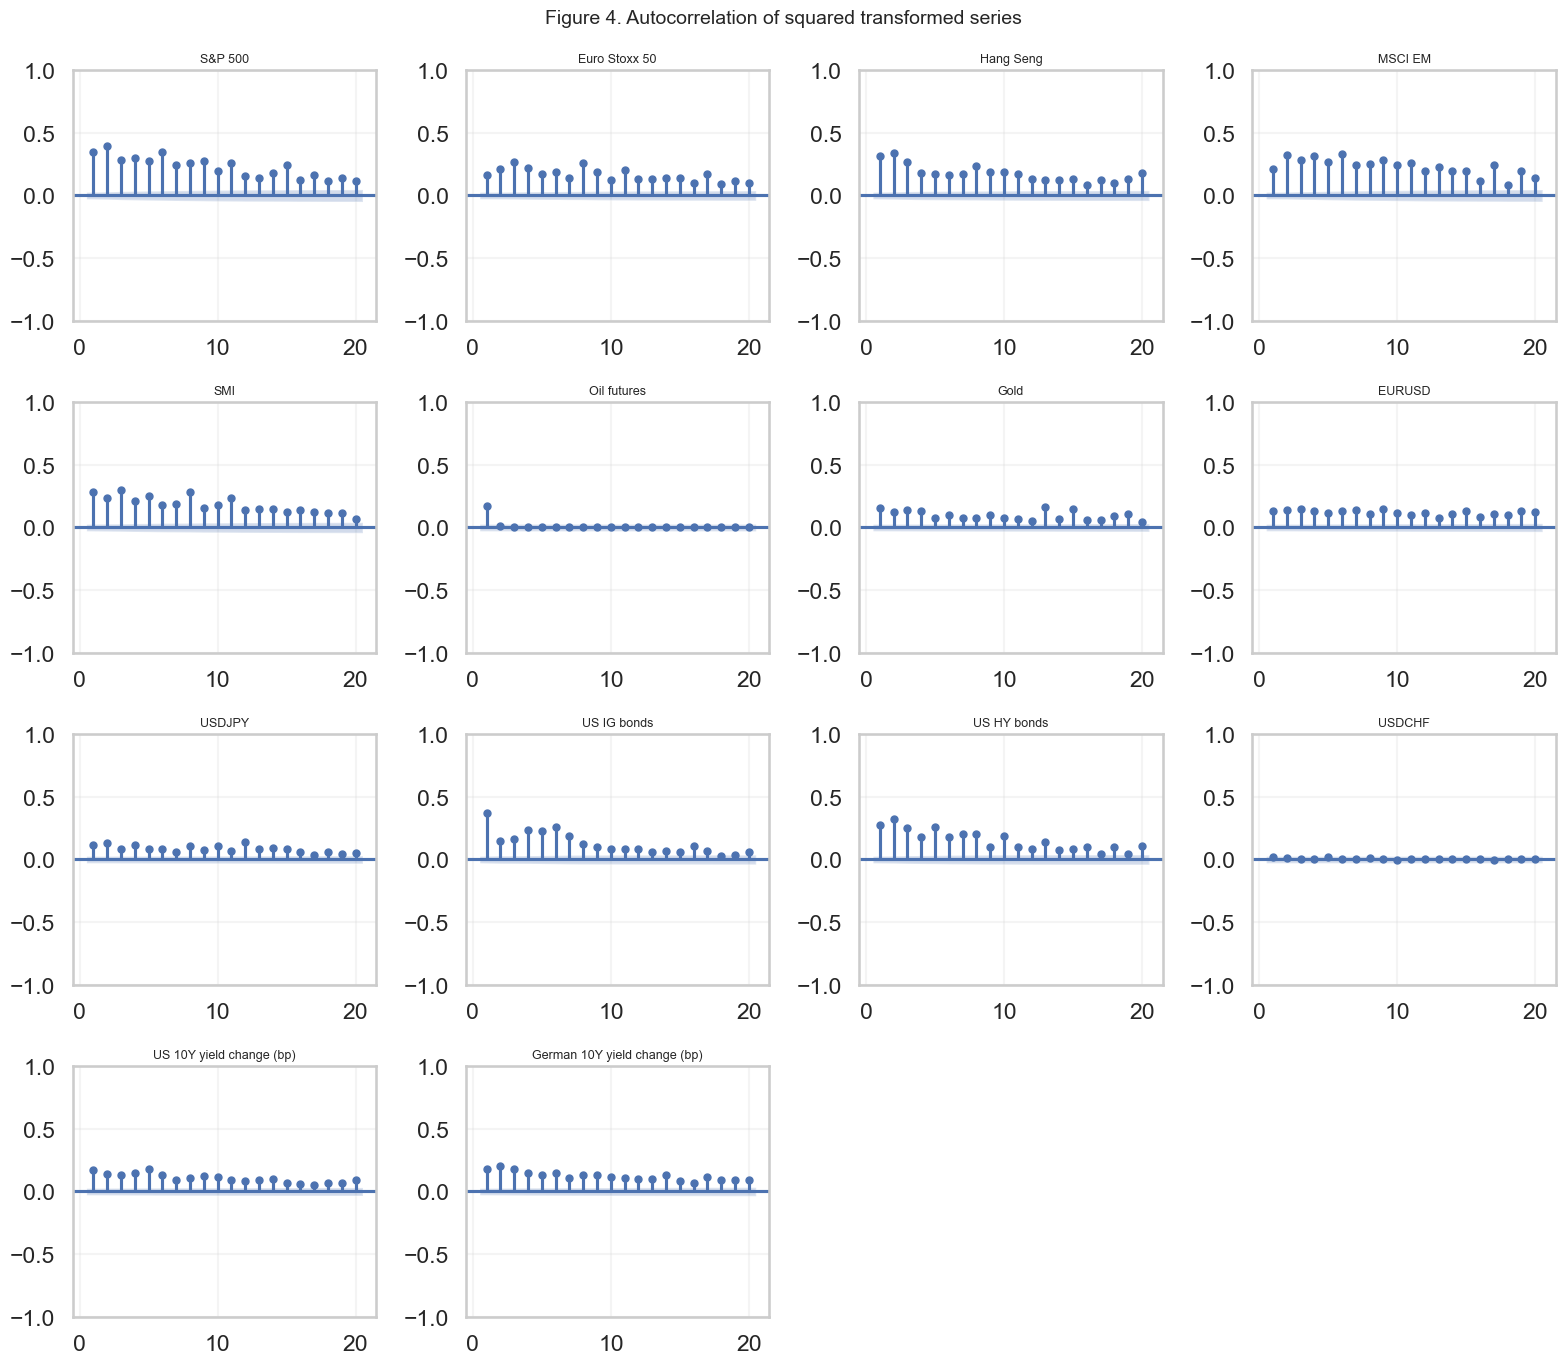

In [3]:
stylized_facts = build_stylized_facts_table(pre_covid, post_covid)
stylized_facts["sample"] = stylized_facts["sample"].replace({
    "Pre-COVID": "Pre-COVID (2000-2019)",
    "Post-COVID": "Post-COVID (2020+)",
})
stylized_facts.to_csv(TABLE_DIR / "01_stylized_facts_pre_post.csv", index=False)
aligned_returns.to_csv(TABLE_DIR / "01_aligned_returns.csv", index=False)
pre_covid.to_csv(TABLE_DIR / "01_pre_covid_returns.csv", index=False)
post_covid.to_csv(TABLE_DIR / "01_post_covid_returns.csv", index=False)

stationarity_table = stationarity_test_table(
    {
        "Pre-COVID (2000-2019)": pre_covid,
        "Post-COVID (2020+)": post_covid,
    },
    ["sp500", "ust10y_yield", "oil", "eurusd", "us_hy_bonds"],
)
stationarity_table.to_csv(TABLE_DIR / "01_stationarity_tests.csv", index=False)

key_assets = ["sp500", "ust10y_yield", "oil", "us_hy_bonds"]
display(stylized_facts.loc[stylized_facts["asset"].isin(key_assets)].sort_values(["sample", "asset"]))
display(stationarity_table)

level_figure = plot_level_panel(level_data, ["sp500", "ust10y_yield", "oil", "gold"], "Figure 1. Selected market levels")
corr_figure = plot_correlation_heatmaps(pre_covid, post_covid)
acf_figure = plot_acf_grid(aligned_returns, "Figure 3. Autocorrelation of daily transformed series", squared=False)
acf_sq_figure = plot_acf_grid(aligned_returns, "Figure 4. Autocorrelation of squared transformed series", squared=True)

save_figure(level_figure, "01_level_panel.png")
save_figure(corr_figure, "01_pre_post_correlation_heatmaps.png")
save_figure(acf_figure, "01_return_acf_grid.png")
save_figure(acf_sq_figure, "01_squared_return_acf_grid.png")

plt.show()

,break_date,f_stat,p_value,pre_variance_mean,post_variance_mean,n_pre,n_post
0,2020-03-11,3.7054,0.0543,1.3794,1.6972,4218,1268


,cusum_stat,cusum_pvalue,cusum_critical_1pct,cusum_critical_5pct,cusum_critical_10pct
0,1.7150,0.0056,1.6300,1.3600,1.2200


,break_date,f_stat,p_value_chow_style
0,2011-12-21,24.1251,0.0000
1,2011-12-22,24.0501,0.0000
2,2011-12-23,24.0084,0.0000
3,2011-12-01,24.0053,0.0000
4,2011-12-29,23.9735,0.0000


,break_index,break_date
0,1805,2008-08-26
1,1870,2008-12-18
2,2510,2011-12-23


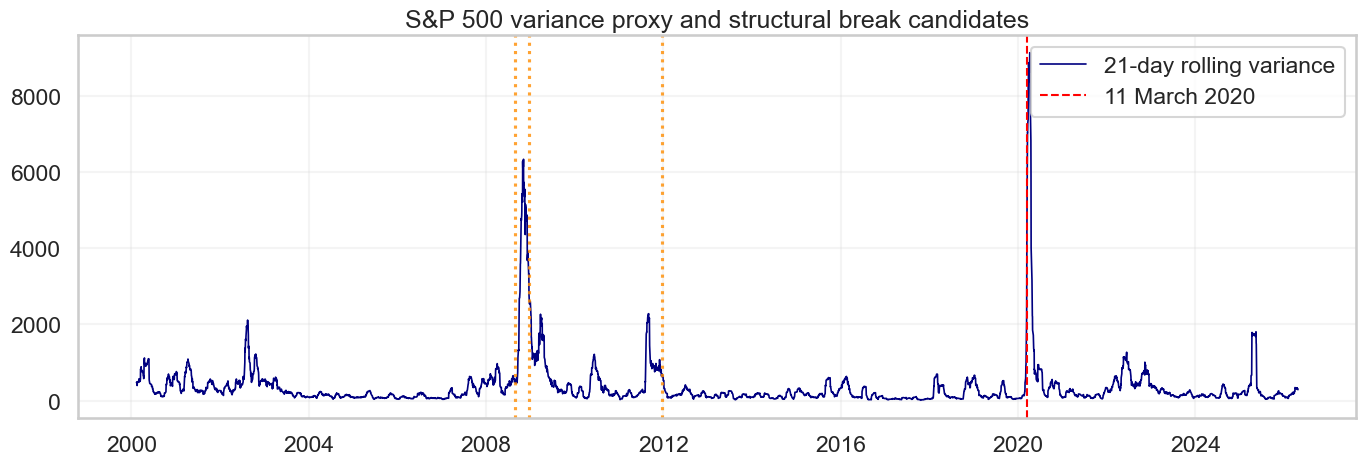

In [4]:
# We use squared S&P 500 returns as a daily variance proxy, which is standard in empirical finance.
sp500_variance_proxy = pd.Series(
    aligned_returns["sp500"].to_numpy() ** 2,
    index=pd.to_datetime(aligned_returns["date"]),
    name="sp500_squared_return",
)

covid_break_test = variance_chow_test(sp500_variance_proxy, COVID_BREAK)
cusum_break_test = cusum_variance_break_test(sp500_variance_proxy)
quandt_table = quandt_andrews_style_variance_test(sp500_variance_proxy, trim=0.15)
break_table = bai_perron_style_breaks(sp500_variance_proxy, n_breaks=3, min_size=63)

pd.DataFrame([covid_break_test]).to_csv(TABLE_DIR / "01_chow_variance_break_at_covid.csv", index=False)
pd.DataFrame([cusum_break_test]).to_csv(TABLE_DIR / "01_cusum_variance_break_test.csv", index=False)
quandt_table.to_csv(TABLE_DIR / "01_quandt_andrews_variance_scan.csv", index=False)
break_table.to_csv(TABLE_DIR / "01_bai_perron_variance_breaks.csv", index=False)

variance_break_figure = plot_variance_breaks(aligned_returns.set_index("date")["sp500"], COVID_BREAK, break_table)
save_figure(variance_break_figure, "01_sp500_variance_breaks.png")

display(pd.DataFrame([covid_break_test]))
display(pd.DataFrame([cusum_break_test]))
display(quandt_table.head(5))
display(break_table)

plt.show()

## 5. Univariate volatility: did persistence or asymmetry change?

The next step is to check whether post-COVID market risk became more persistent or more asymmetric. We use three standard models from the course — GARCH(1,1), GJR-GARCH and GARCH-t — on four key assets: S&P 500, US HY bonds, oil and gold.


,asset,sample,model,alpha_1,beta_1,gamma_1,nu,persistence,lb_resid_pvalue_lag10,lb_sq_resid_pvalue_lag10,engle_ng_joint_pvalue,asset_label
0,gold,Post-COVID (2020+),"GARCH(1,1)",0.1377,0.7936,NaN,NaN,0.9313,0.8584,0.9148,0.1774,Gold
1,gold,Post-COVID (2020+),GARCH-t,0.1048,0.8369,NaN,5.0668,0.9417,0.8500,0.7519,0.5515,Gold
2,gold,Post-COVID (2020+),GJR-GARCH,0.1820,0.8267,-0.1191,NaN,0.9492,0.8774,0.8578,0.4941,Gold
3,gold,Pre-COVID (2000-2019),"GARCH(1,1)",0.0459,0.9438,NaN,NaN,0.9897,0.7235,0.0008,0.7489,Gold
4,gold,Pre-COVID (2000-2019),GARCH-t,0.0442,0.9484,NaN,5.3948,0.9926,0.7108,0.0002,0.7718,Gold
5,gold,Pre-COVID (2000-2019),GJR-GARCH,0.0518,0.9441,-0.0108,NaN,0.9906,0.7262,0.0000,0.6502,Gold
6,oil,Post-COVID (2020+),"GARCH(1,1)",0.1080,0.8920,NaN,NaN,1.0000,0.6598,1.0000,0.1440,Oil futures
7,oil,Post-COVID (2020+),GARCH-t,0.2019,0.6949,NaN,4.8872,0.8968,0.4362,1.0000,0.3069,Oil futures
8,oil,Post-COVID (2020+),GJR-GARCH,0.0884,0.0911,1.6410,NaN,1.0000,0.0005,0.2022,0.0872,Oil futures
9,oil,Pre-COVID (2000-2019),"GARCH(1,1)",0.0797,0.9105,NaN,NaN,0.9902,0.6798,0.7615,0.0010,Oil futures


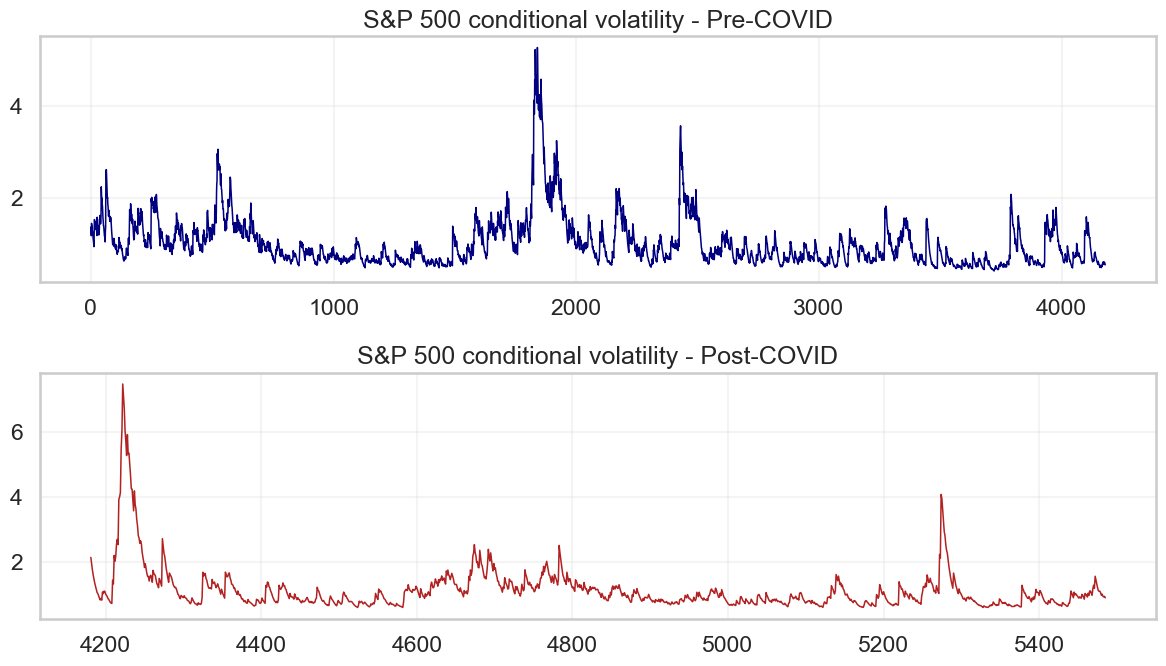

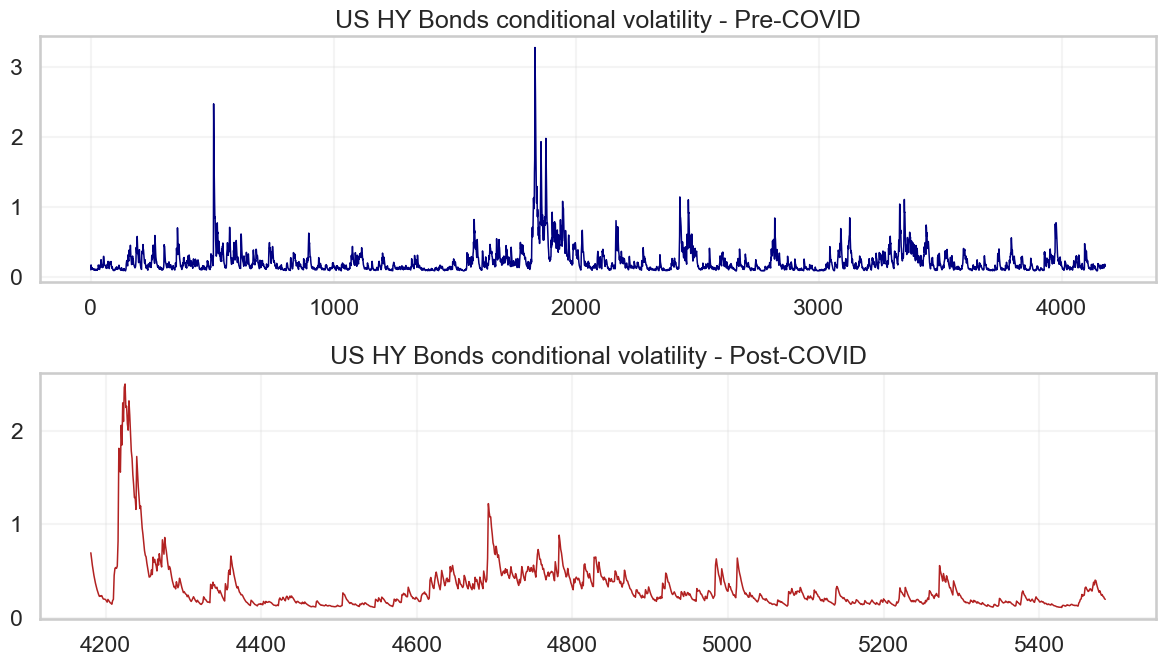

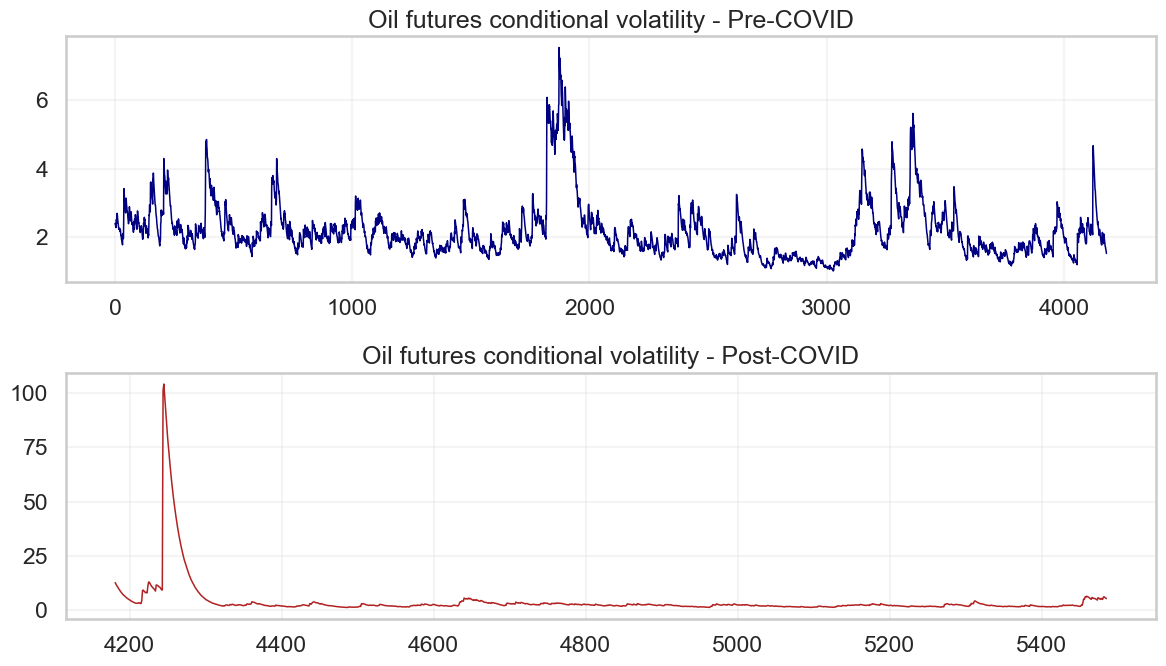

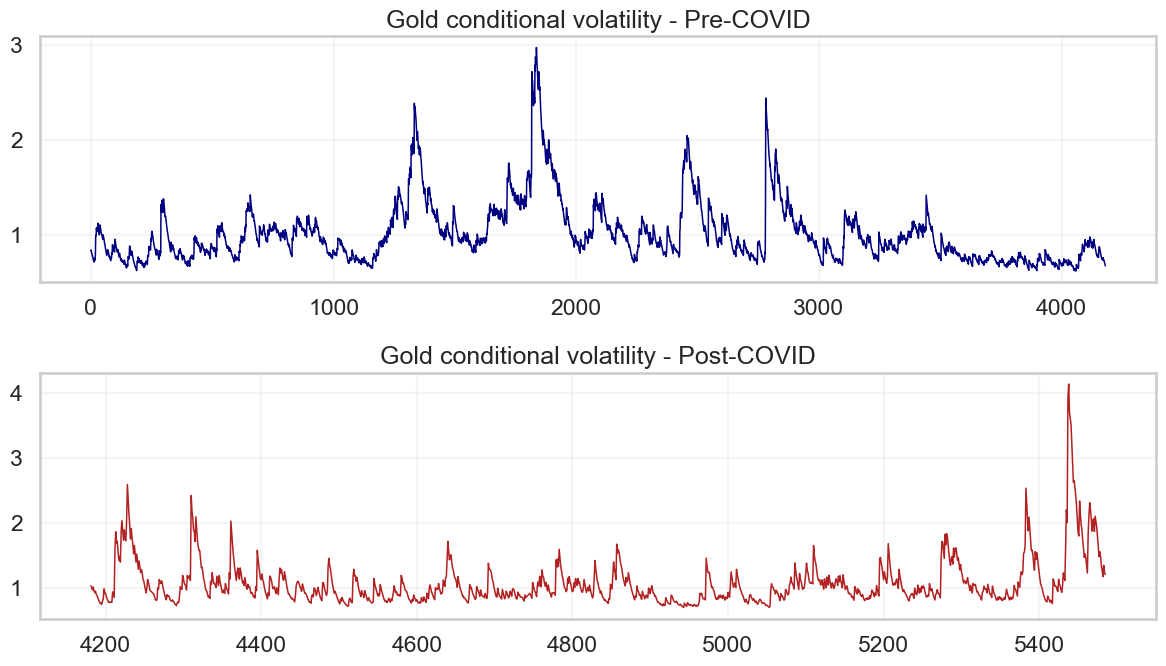

In [5]:
garch_summary = estimate_all_garch_models(pre_covid, post_covid)
garch_summary["sample"] = garch_summary["sample"].replace({
    "Pre-COVID": "Pre-COVID (2000-2019)",
    "Post-COVID": "Post-COVID (2020+)",
})
save_garch_outputs(garch_summary)

garch_comparison = build_comparison_table(garch_summary)
display(garch_comparison.sort_values(["asset_label", "sample", "model"]).reset_index(drop=True))

for asset_name in GARCH_ASSETS:
    figure = plot_conditional_volatility(pre_covid[asset_name], post_covid[asset_name], asset_name)
    save_figure(figure, f"02_conditional_volatility_{asset_name}.png")
    plt.show()


## 6. Dependence and co-movement after COVID

A structural change in risk should also appear in the way markets move together. We therefore start with rolling correlations on a small set of economically relevant pairs, then estimate DCC-GARCH models for two benchmark links: one rate-sensitive pair (**SPX / US 10Y**) and one credit-sensitive pair (**SPX / US HY Bonds**). Finally, we report the Forbes-Rigobon correction for the SPX / US 10Y correlation so that we do not confuse changing dependence with a purely mechanical volatility effect.

,pair,pre_mean_rolling_corr,post_mean_rolling_corr,change_post_minus_pre,pre_std_rolling_corr,post_std_rolling_corr,pre_min_rolling_corr,post_min_rolling_corr,pre_max_rolling_corr,post_max_rolling_corr
0,S&P 500 vs US 10Y yield change,0.3450,0.0916,-0.2534,0.1996,0.2756,-0.1205,-0.2274,0.7128,0.6437
1,S&P 500 vs US HY Bonds,0.3018,0.5730,0.2712,0.1490,0.0689,-0.0661,0.3847,0.6132,0.8224
2,S&P 500 vs Oil futures,0.2078,0.1409,-0.0669,0.2220,0.1040,-0.2019,-0.0713,0.6321,0.5222
3,Gold vs US 10Y yield change,-0.2053,-0.3346,-0.1293,0.1772,0.1292,-0.6728,-0.5884,0.1715,-0.0454


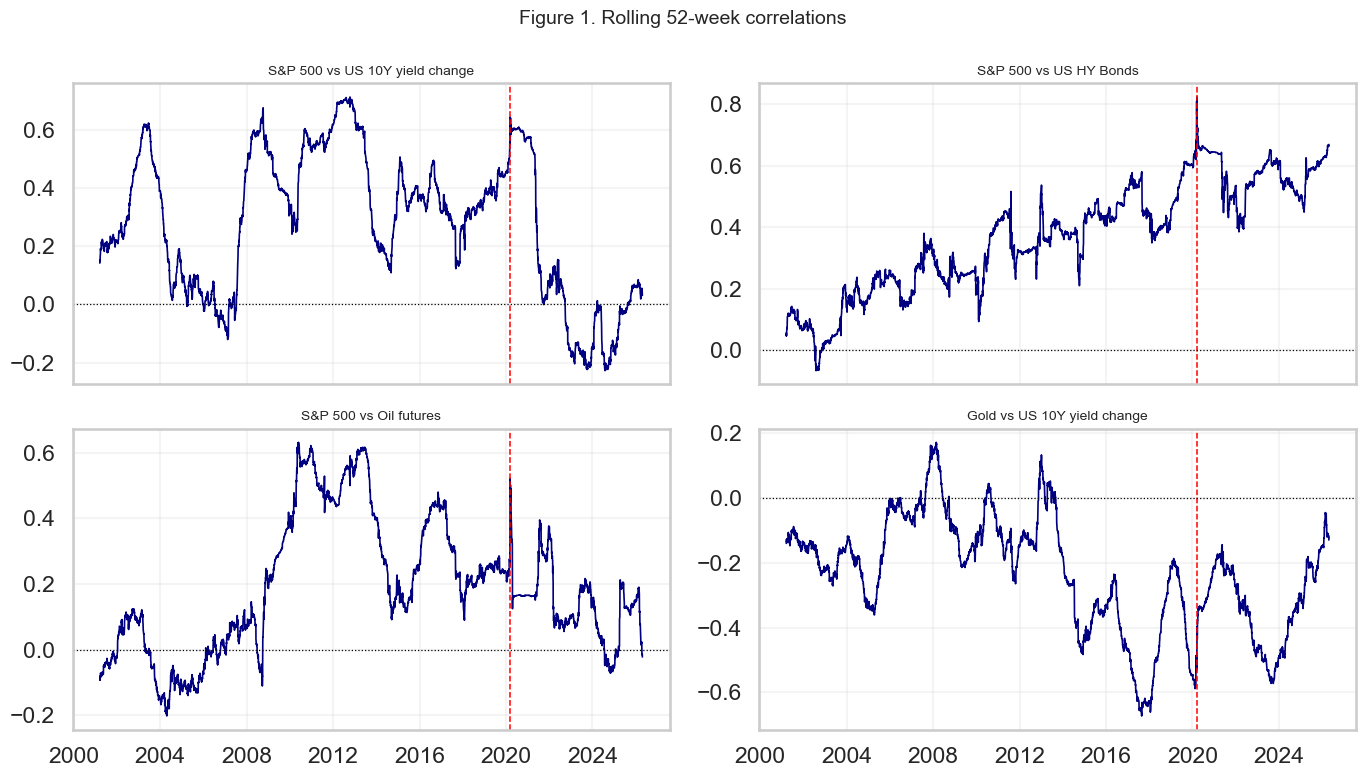

,pair,dcc_alpha,dcc_alpha_se,dcc_alpha_tstat,dcc_beta,dcc_beta_se,dcc_beta_tstat,dcc_persistence,optimization_success
0,S&P 500 vs US 10Y yield change,0.0555,0.0066,8.3601,0.9238,0.0102,90.1820,0.9793,True
1,S&P 500 vs US HY Bonds,0.0095,0.0041,2.3066,0.9872,0.0077,127.4734,0.9968,True


,pre_mean_dcc_corr,post_mean_dcc_corr,change_post_minus_pre,pre_std_dcc_corr,post_std_dcc_corr,pre_min_dcc_corr,post_min_dcc_corr,pre_max_dcc_corr,post_max_dcc_corr,pair
0,0.3068,0.0876,-0.2191,0.2331,0.2507,-0.4263,-0.4848,0.7807,0.6736,S&P 500 vs US 10Y yield change
1,0.3256,0.5120,0.1864,0.1131,0.0488,0.0643,0.3733,0.6272,0.6292,S&P 500 vs US HY Bonds


,raw_pre_corr,raw_post_corr,sp500_variance_ratio_post_pre,ust10y_variance_ratio_post_pre,forbes_rigobon_adjusted_post_corr,difference_adjusted_post_minus_pre
0,0.3872,0.1167,1.3152,1.1122,0.1020,-0.2853


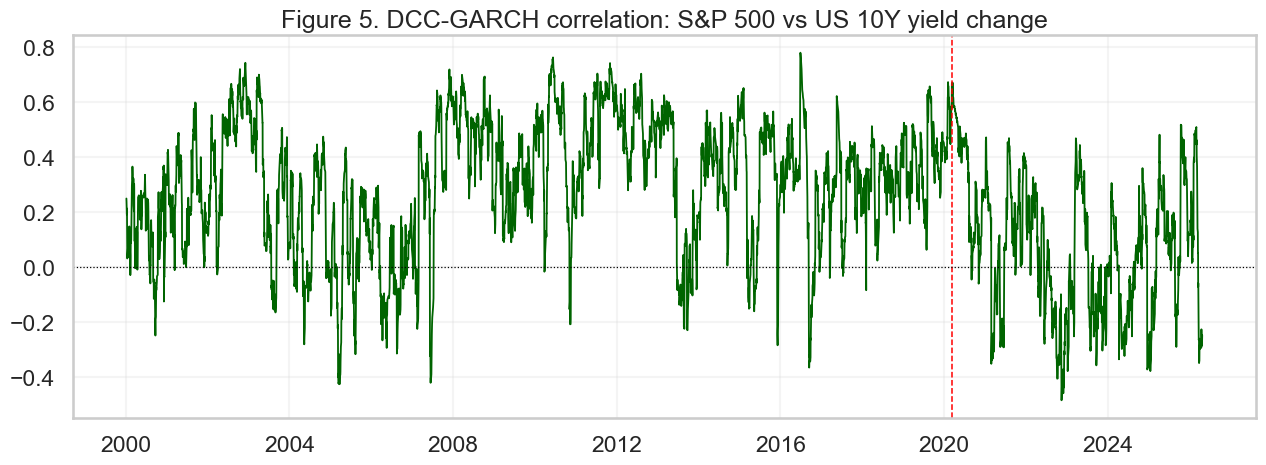

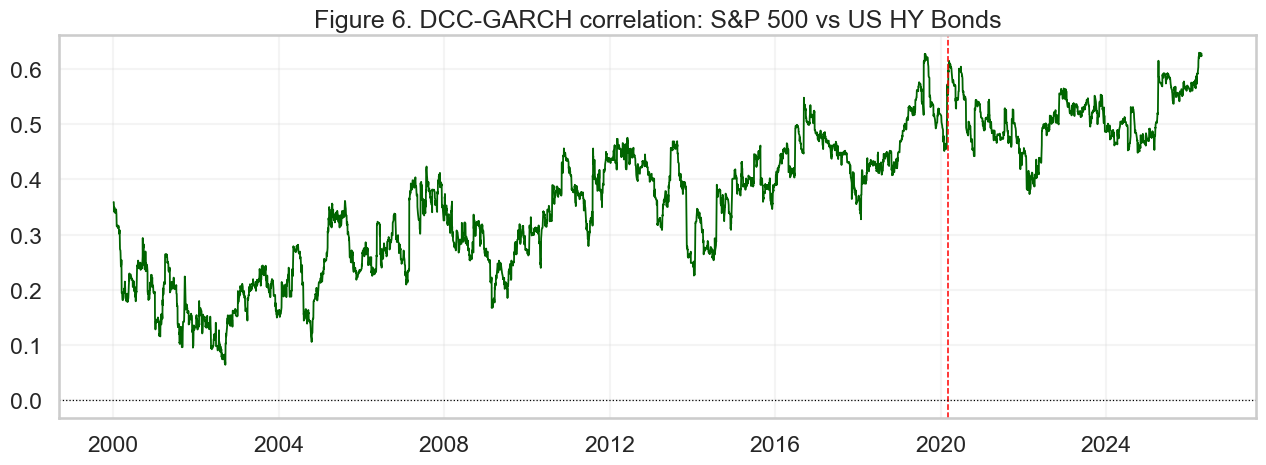

In [6]:
rolling_corr = rolling_correlation_table(aligned_returns, KEY_PAIRS)
rolling_summary = summarize_rolling_correlations(rolling_corr)
rolling_summary.to_csv(TABLE_DIR / "03_rolling_correlation_summary.csv", index=False)

rolling_figure = plot_rolling_correlations(rolling_corr)
save_figure(rolling_figure, "03_rolling_correlations.png")
display(rolling_summary)
plt.show()

spx_ust_input = aligned_returns[["date", "sp500", "ust10y_yield"]].dropna().copy()
spx_hy_input = aligned_returns[["date", "sp500", "us_hy_bonds"]].dropna().copy()

spx_ust_result = fit_bivariate_dcc(spx_ust_input, pair_name=PAIR_LABELS[DCC_PAIRS[0]])
spx_hy_result = fit_bivariate_dcc(spx_hy_input, pair_name=PAIR_LABELS[DCC_PAIRS[1]])

dcc_parameter_summary = pd.DataFrame([
    {
        "pair": spx_ust_result["pair"],
        "dcc_alpha": spx_ust_result["alpha"],
        "dcc_alpha_se": spx_ust_result["alpha_se"],
        "dcc_alpha_tstat": spx_ust_result["alpha_tstat"],
        "dcc_beta": spx_ust_result["beta"],
        "dcc_beta_se": spx_ust_result["beta_se"],
        "dcc_beta_tstat": spx_ust_result["beta_tstat"],
        "dcc_persistence": spx_ust_result["persistence"],
        "optimization_success": spx_ust_result["success"],
    },
    {
        "pair": spx_hy_result["pair"],
        "dcc_alpha": spx_hy_result["alpha"],
        "dcc_alpha_se": spx_hy_result["alpha_se"],
        "dcc_alpha_tstat": spx_hy_result["alpha_tstat"],
        "dcc_beta": spx_hy_result["beta"],
        "dcc_beta_se": spx_hy_result["beta_se"],
        "dcc_beta_tstat": spx_hy_result["beta_tstat"],
        "dcc_persistence": spx_hy_result["persistence"],
        "optimization_success": spx_hy_result["success"],
    },
])

dcc_path_summary = pd.concat([
    summarize_dcc_path(spx_ust_result["dcc_path"]).assign(pair=spx_ust_result["pair"]),
    summarize_dcc_path(spx_hy_result["dcc_path"]).assign(pair=spx_hy_result["pair"]),
], ignore_index=True)
fr_table = build_forbes_rigobon_table(pre_covid, post_covid)
save_multivariate_outputs(
    rolling_summary,
    dcc_parameter_summary,
    dcc_path_summary,
    fr_table,
    {
        "spx_ust": spx_ust_result["dcc_path"],
        "spx_hy": spx_hy_result["dcc_path"],
    },
)

display(dcc_parameter_summary)
display(dcc_path_summary)
display(fr_table)

dcc_spx_ust_figure = plot_dcc_path(spx_ust_result["dcc_path"], "Figure 5. DCC-GARCH correlation: S&P 500 vs US 10Y yield change")
dcc_spx_hy_figure = plot_dcc_path(spx_hy_result["dcc_path"], "Figure 6. DCC-GARCH correlation: S&P 500 vs US HY Bonds")
save_figure(dcc_spx_ust_figure, "03_spx_ust_dcc.png")
save_figure(dcc_spx_hy_figure, "03_spx_hy_dcc.png")
plt.show()

## 7. Risk transmission: VAR(2), Granger and Geweke causality

The project brief explicitly asks for a **VAR(2)** on five core variables. We keep that benchmark specification, but we also report lag-selection criteria so that the imposed lag length remains transparent. We then use Granger and Geweke measures to distinguish between lagged forecast content and residual contemporaneous dependence.

C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

,sample,AIC,BIC,HQIC,FPE
0,Pre-COVID (2000-2019),5,1,2,5
1,Post-COVID (2020+),5,1,2,5


,sample,lag_order,n_obs,aic,bic,hqic,stable,smallest_root_modulus
0,Pre-COVID (2000-2019),2,4179,1.1796,1.2630,1.2091,True,1.8245
1,Post-COVID (2020+),2,1303,4.3397,4.5580,4.4216,True,2.0410


,sample,caused,causing,granger_f_stat,granger_pvalue
38,Post-COVID (2020+),us_hy_bonds,oil,10.3253,0.0000
39,Post-COVID (2020+),us_hy_bonds,eurusd,9.9762,0.0000
36,Post-COVID (2020+),us_hy_bonds,sp500,5.8858,0.0028
21,Post-COVID (2020+),sp500,oil,5.4384,0.0044
27,Post-COVID (2020+),ust10y_yield,us_hy_bonds,4.9061,0.0074
16,Pre-COVID (2000-2019),us_hy_bonds,sp500,155.5630,0.0000
3,Pre-COVID (2000-2019),sp500,us_hy_bonds,19.4501,0.0000
12,Pre-COVID (2000-2019),eurusd,sp500,8.2830,0.0003
19,Pre-COVID (2000-2019),us_hy_bonds,eurusd,5.1713,0.0057
8,Pre-COVID (2000-2019),oil,sp500,4.6145,0.0099


,sample,measure,causing,caused,geweke_value,test_stat,pvalue
41,Post-COVID (2020+),directional,oil,us_hy_bonds,0.0159,20.6617,0.0000
45,Post-COVID (2020+),directional,eurusd,us_hy_bonds,0.0153,19.9686,0.0000
33,Post-COVID (2020+),directional,sp500,us_hy_bonds,0.0091,11.8180,0.0027
38,Post-COVID (2020+),directional,oil,sp500,0.0084,10.9236,0.0042
47,Post-COVID (2020+),directional,us_hy_bonds,ust10y_yield,0.0076,9.8584,0.0072
53,Post-COVID (2020+),instantaneous,sp500,us_hy_bonds,0.5914,770.5709,0.0000
55,Post-COVID (2020+),instantaneous,ust10y_yield,eurusd,0.0570,74.2911,0.0000
59,Post-COVID (2020+),instantaneous,eurusd,us_hy_bonds,0.0663,86.3510,0.0000
52,Post-COVID (2020+),instantaneous,sp500,eurusd,0.0379,49.3324,0.0000
56,Post-COVID (2020+),instantaneous,ust10y_yield,us_hy_bonds,0.0144,18.7019,0.0000


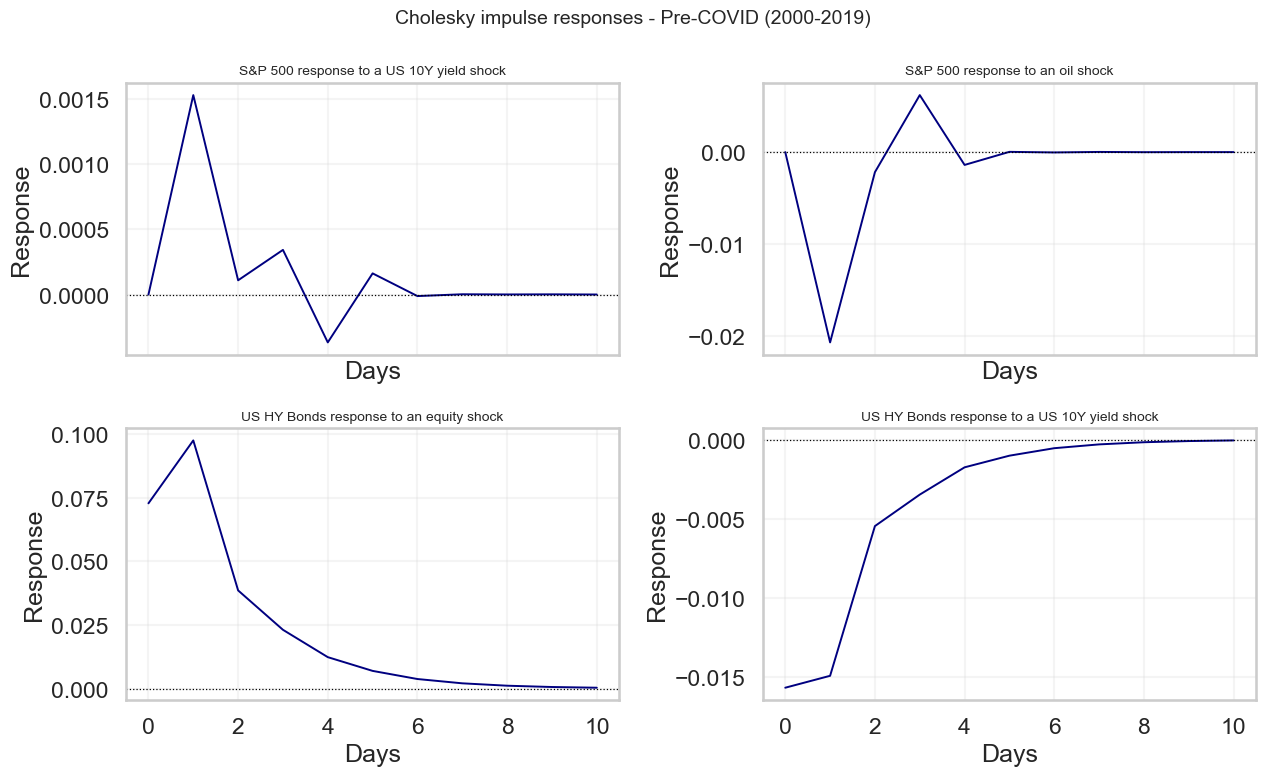

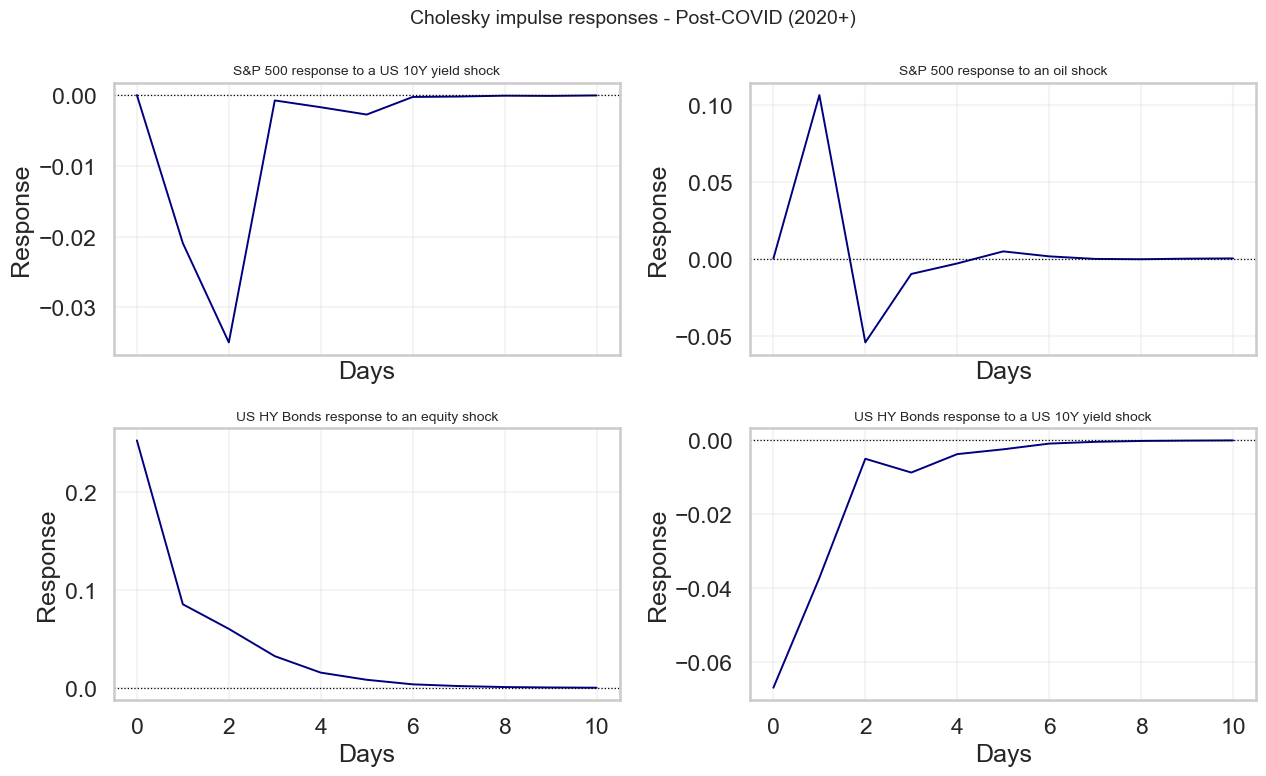

In [7]:
aligned_var = aligned_returns[["date"] + VAR_COLUMNS].dropna().copy()
var_order_table = pd.concat([
    var_order_selection(pre_covid[["date"] + VAR_COLUMNS].dropna(), max_lags=6).assign(sample="Pre-COVID (2000-2019)"),
    var_order_selection(post_covid[["date"] + VAR_COLUMNS].dropna(), max_lags=6).assign(sample="Post-COVID (2020+)"),
], ignore_index=True)

var_pre = fit_var(pre_covid[["date"] + VAR_COLUMNS].dropna())
var_post = fit_var(post_covid[["date"] + VAR_COLUMNS].dropna())

var_summary = pd.DataFrame([
    var_summary_row(var_pre, "Pre-COVID (2000-2019)"),
    var_summary_row(var_post, "Post-COVID (2020+)"),
])
granger_results = pd.concat([
    granger_table(var_pre, "Pre-COVID (2000-2019)"),
    granger_table(var_post, "Post-COVID (2020+)"),
], ignore_index=True)
geweke_results = pd.concat([
    geweke_causality_table(var_pre, pre_covid[["date"] + VAR_COLUMNS].dropna(), "Pre-COVID (2000-2019)", lag_order=VAR_LAG),
    geweke_causality_table(var_post, post_covid[["date"] + VAR_COLUMNS].dropna(), "Post-COVID (2020+)", lag_order=VAR_LAG),
], ignore_index=True)
save_var_outputs(var_summary, granger_results, geweke_results)
var_order_table.to_csv(TABLE_DIR / "04_var_order_selection.csv", index=False)

display(var_order_table[["sample", "AIC", "BIC", "HQIC", "FPE"]])
display(var_summary)
display(granger_results.sort_values(["sample", "granger_pvalue"]).groupby("sample").head(5))
display(geweke_results.sort_values(["sample", "measure", "pvalue"]).groupby(["sample", "measure"]).head(5))

irf_pre_figure = plot_irf_panel(var_pre, "Pre-COVID (2000-2019)")
irf_post_figure = plot_irf_panel(var_post, "Post-COVID (2020+)")
save_figure(irf_pre_figure, "04_irf_pre_covid.png")
save_figure(irf_post_figure, "04_irf_post_covid.png")
plt.show()

## 8. Regimes and structural breaks

If COVID changed the structure of risk, the effect should not appear only in moments or filtered correlations. It should also show up as **regime switches** and **multiple structural breaks**. We therefore combine a two-state Markov-switching model on the SPX / US 10Y rolling correlation with Bai-Perron-style break detection on both rolling variance and rolling correlation. For reproducibility, the Markov model uses a fixed random seed before estimation.

C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,regime,estimated_mean,estimated_variance,avg_smoothed_probability,label
0,0.0000,0.4693,0.0146,0.5602,higher-correlation regime
1,1.0000,0.0431,0.0180,0.4398,lower-correlation regime
2,NaN,NaN,NaN,0.4395,share of time in lower-correlation regime


,break_index,break_date,series_mean_before_break
0,1755,2008-09-17,310.9178
1,1855,2009-03-19,441.5470
2,2480,2012-02-24,459.8589


,break_index,break_date,series_mean_before_break
0,635,2004-04-22,0.3626
1,1385,2007-11-02,0.1928
2,4240,2021-06-23,0.3598


,n_breaks_pre_covid,n_breaks_post_covid,series
0,3,0,SP500 rolling variance
1,2,1,SPX/UST rolling correlation


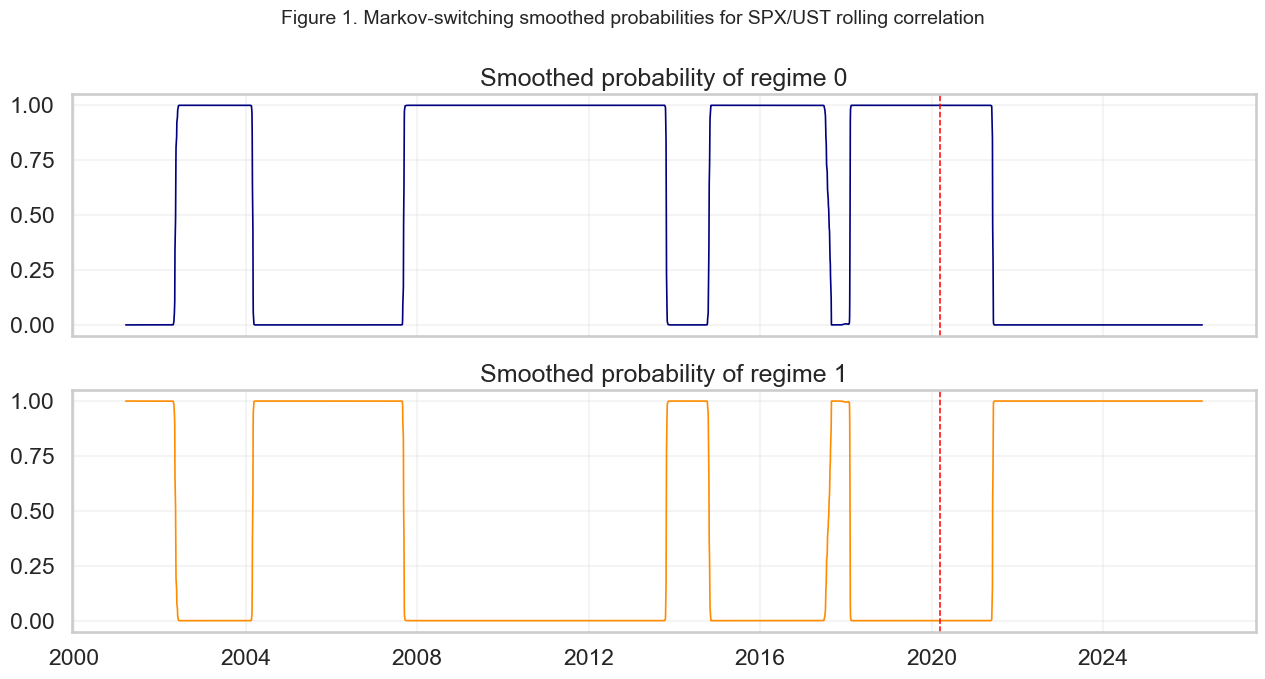

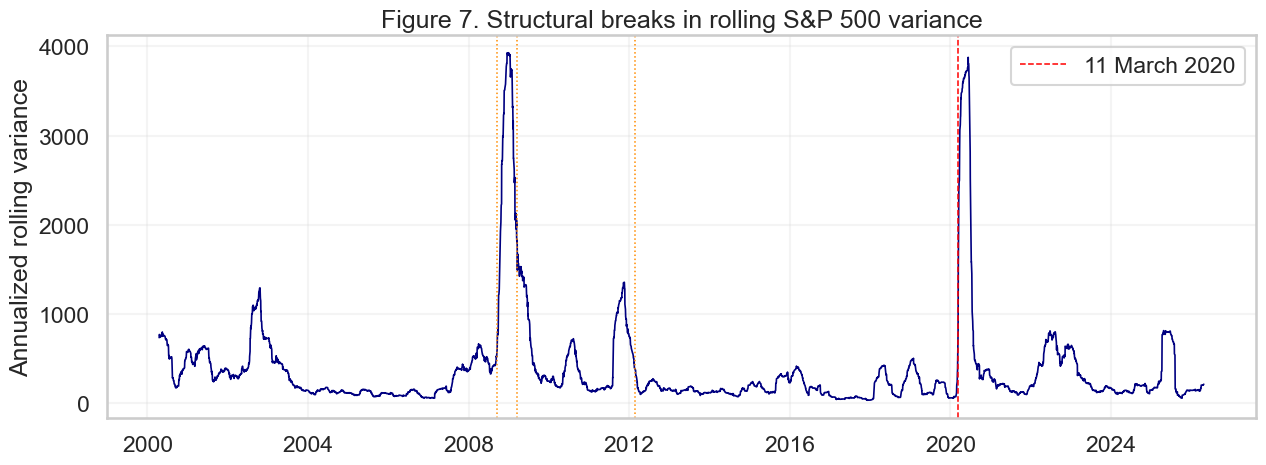

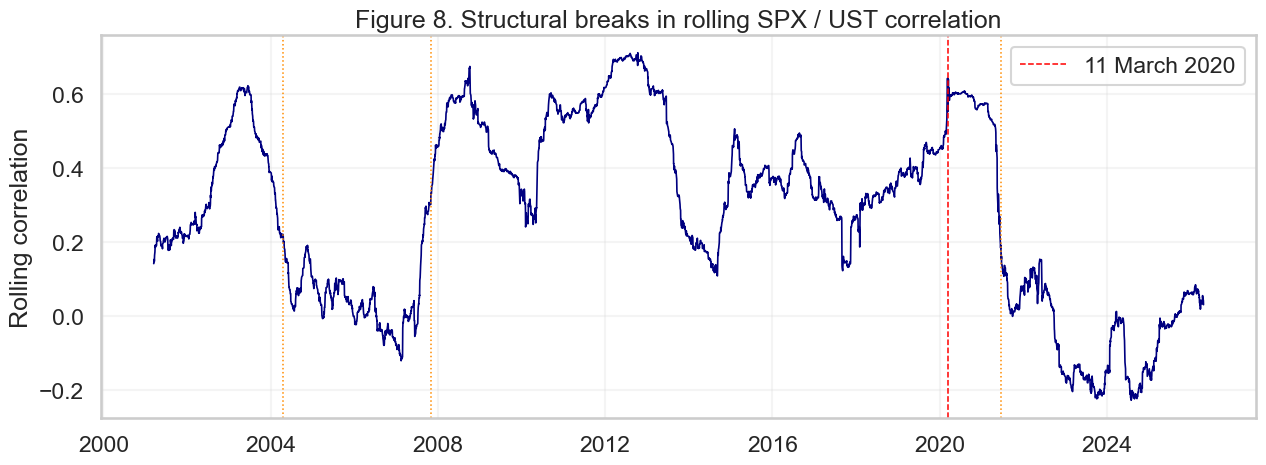

In [8]:
rolling_variance, spx_ust_corr = load_regime_data()

markov_result = fit_two_state_markov(spx_ust_corr)
markov_summary = markov_summary_table(markov_result)
smoothed_probs = smoothed_probability_table(markov_result)

variance_breaks = run_break_detection(
    rolling_variance.set_index("date")["sp500_rolling_variance"],
    n_breaks=3,
    min_size=63,
)
corr_breaks = run_break_detection(
    spx_ust_corr.set_index("date")["spx_ust_rolling_corr"],
    n_breaks=3,
    min_size=63,
)
save_regime_outputs(markov_summary, smoothed_probs, variance_breaks, corr_breaks)

variance_break_count = pre_post_break_count(variance_breaks)
corr_break_count = pre_post_break_count(corr_breaks)

display(markov_summary)
display(variance_breaks)
display(corr_breaks)
display(pd.concat([
    variance_break_count.assign(series="SP500 rolling variance"),
    corr_break_count.assign(series="SPX/UST rolling correlation"),
], ignore_index=True))

prob_figure = plot_smoothed_probabilities(smoothed_probs)
variance_figure = plot_breaks(
    rolling_variance.set_index("date")["sp500_rolling_variance"],
    variance_breaks,
    "Figure 7. Structural breaks in rolling S&P 500 variance",
    "Annualized rolling variance",
)
corr_figure = plot_breaks(
    spx_ust_corr.set_index("date")["spx_ust_rolling_corr"],
    corr_breaks,
    "Figure 8. Structural breaks in rolling SPX / UST correlation",
    "Rolling correlation",
)

save_figure(prob_figure, "05_markov_smoothed_probabilities.png")
save_figure(variance_figure, "05_sp500_variance_breaks.png")
save_figure(corr_figure, "05_spx_ust_corr_breaks.png")
plt.show()


## 9. Synthesis: what changed after COVID?

We can now answer the research question by combining the evidence across levels, persistence, co-movement, transmission and regimes.


In [9]:
final_summary = pd.DataFrame([
    {
        "dimension": "Tail risk and higher moments",
        "main evidence": "Post-2020 stylized facts show fatter tails, non-normality and different downside risk profiles across markets.",
    },
    {
        "dimension": "Stationarity of transformed series",
        "main evidence": "ADF and KPSS tests support the use of transformed daily series as the workhorse inputs for GARCH, DCC and VAR models.",
    },
    {
        "dimension": "Volatility persistence",
        "main evidence": "GARCH persistence remains high and post-COVID asymmetry is stronger for selected assets, especially credit and equities.",
    },
    {
        "dimension": "Cross-asset dependence",
        "main evidence": "Rolling correlations and DCC show that both the SPX / US 10Y link and the SPX / US HY link changed materially after COVID.",
    },
    {
        "dimension": "Risk transmission",
        "main evidence": "VAR, Granger and Geweke results indicate that lead-lag and contemporaneous spillovers differ across the two subsamples.",
    },
    {
        "dimension": "Regimes and breaks",
        "main evidence": "Markov-switching and Bai-Perron-style break detection confirm that the dependence structure is not stable over the full sample.",
    },
])
display(final_summary)

,dimension,main evidence
0,Tail risk and higher moments,"Post-2020 stylized facts show fatter tails, no..."
1,Stationarity of transformed series,ADF and KPSS tests support the use of transfor...
2,Volatility persistence,GARCH persistence remains high and post-COVID ...
3,Cross-asset dependence,Rolling correlations and DCC show that both th...
4,Risk transmission,"VAR, Granger and Geweke results indicate that ..."
5,Regimes and breaks,Markov-switching and Bai-Perron-style break de...


## 10. Compliance check against the project brief

Before closing, we verify explicitly that the notebook matches both the prompt and the PDF instructions.


In [10]:
compliance_table = pd.DataFrame([
    {"requirement": "Only Data.xlsx is used", "status": "Yes", "comment": "The pipeline loads only data/raw/Data.xlsx (or Data (1).xlsx as a local fallback name)."},
    {"requirement": "No external data source", "status": "Yes", "comment": "No FRED, Yahoo, VIX or macro series outside the workbook are used."},
    {"requirement": "No forbidden methods", "status": "Yes", "comment": "No machine learning, copulas, intraday data or BEKK-GARCH are used."},
    {"requirement": "14 series loaded and aligned", "status": "Yes", "comment": "The full workbook is loaded and NaN handling is done after transformation by aligned dropping."},
    {"requirement": "Yields are not log-transformed", "status": "Yes", "comment": "US and German 10Y yields are converted into first differences in basis points."},
    {"requirement": "Pre/Post comparison", "status": "Yes", "comment": "The main split is 2000-2019 vs 2020+, which matches the prompt wording."},
    {"requirement": "11 March 2020 break date justified", "status": "Yes", "comment": "Variance Chow-style, CUSUM, Quandt-Andrews-style and Bai-Perron-style break procedures are reported."},
    {"requirement": "Notebook runs end-to-end", "status": "Yes", "comment": "This notebook reproduces the full pipeline without relying on precomputed outputs."},
    {"requirement": "Oil log-return issue addressed transparently", "status": "Qualified yes", "comment": "Oil uses simple returns because negative WTI prices make log returns undefined in April 2020."},
])
compliance_table


,requirement,status,comment
0,Only Data.xlsx is used,Yes,The pipeline loads only data/raw/Data.xlsx (or...
1,No external data source,Yes,"No FRED, Yahoo, VIX or macro series outside th..."
2,No forbidden methods,Yes,"No machine learning, copulas, intraday data or..."
3,14 series loaded and aligned,Yes,The full workbook is loaded and NaN handling i...
4,Yields are not log-transformed,Yes,US and German 10Y yields are converted into fi...
5,Pre/Post comparison,Yes,"The main split is 2000-2019 vs 2020+, which ma..."
6,11 March 2020 break date justified,Yes,"Variance Chow-style, CUSUM, Quandt-Andrews-sty..."
7,Notebook runs end-to-end,Yes,This notebook reproduces the full pipeline wit...
8,Oil log-return issue addressed transparently,Qualified yes,Oil uses simple returns because negative WTI p...


## 11. Conclusion

The evidence supports the view that the structure of risk **did change after COVID-19**, but not in a purely one-dimensional way. The strongest changes appear in dependence, transmission and regime behavior rather than in a simple uniform increase in risk across all markets.

For a portfolio manager, this matters because post-COVID diversification, cross-asset hedging and risk monitoring cannot be treated as simple continuations of the pre-2020 sample. The empirical picture is one of **reorganized risk**, not just higher risk.
